# Backtest 005g — TTM Breakout + McClellan Oscillator Regime Filter

Fork of **backtest_005f** that replaces the GKYZ/YZ volatility regime with a
**McClellan Oscillator + Summation Index** breadth filter.

**Regime gate (v1 / v2 only):**
- `summation_index > SMA(summation_index, 20)` — breadth trend is up
- `mcclellan_osc > 0` — net advancing breadth is positive

v3 remains unfiltered.

In [30]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.gkyz_volatility import calculate_gkyz_volatility
from backend.app.services.indicators.yang_zhang_volatility import calculate_yz_volatility
from backend.app.services.indicators.vwap import avwap_func_nb

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [31]:
REMOTE_HOST = 'http://192.168.1.3:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake ...')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} -> {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-06-06 00:00:00 -> 2026-06-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,7.03,15.6,24.9,43.7,9.06,12.00,14.55,21.6,5.55,5.86,...,1844.54,59.1,12.4,26.95,3.14,62.9,31.20,19.85,65.3,8.83
2026-06-02,6.98,15.8,25.1,43.4,9.06,11.95,14.30,21.1,5.47,5.86,...,1826.47,58.6,12.2,26.45,3.04,61.9,31.00,19.25,65.7,9.04
2026-06-03,7.00,15.9,26.0,43.7,9.05,11.95,14.30,21.3,5.46,5.99,...,1819.01,58.3,12.3,26.45,3.01,60.5,30.05,19.65,65.8,9.01


## 2. TTM Breakout Helpers

In [32]:
@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')

Numba helpers compiled


In [33]:
AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP', short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)
_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(close, high, low, volume, is_highest=[False], window=int(window)).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume=None,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3', consecutive_neg_threshold=7,
    william_vix_period=20,
    use_avwap_filter=False, avwap_window=200,
    use_kama_slope=True, kama_period=10, kama_fast=2, kama_slow=30,
    kama_slope_win=5, flat_threshold_pct=1.0,
    mrs_window=21,
):
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    MIN  = vbt.IndicatorFactory.from_talib('MIN')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MIN.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    if use_avwap_filter and volume is not None:
        avwap_lowest = get_avwap_lowest(close, high, low, volume, avwap_window)
        avwap_prev_np = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
        avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    else:
        avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1); ttms_2 = shift_2d(ttms_np, 2); ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np
    else:  # v3
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period, mult=bb_multiplier,
            bbl=bb_window, lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()
        entries_np = wvf_np | entry_2

    # ── Mansfield Relative Strength (MRS) filter — v1 / v2 only ──────────────
    # if entry_version in ('v1', 'v2') and 'VNINDEX' in close.columns:
    #     vnidx_close = close['VNINDEX'].values[:, np.newaxis]
    #     rsd_np      = close.values / vnidx_close * 100
    #     rsd_df      = pd.DataFrame(rsd_np, index=close.index, columns=close.columns)
    #     ma_rsd_np   = rsd_df.rolling(mrs_window).mean().values
    #     with np.errstate(divide='ignore', invalid='ignore'):
    #         mrs_np  = np.where(ma_rsd_np != 0, (rsd_np / ma_rsd_np - 1) * 100, np.nan)
    #     entries_np  = entries_np & (mrs_np > 0)

    entries_np = entries_np & avwap_filter_np
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10, lookback=5):
    """
    Returns (atr_exit, sl_stop_df).
    - atr_exit   : ATR trailing stop crossover signal (dynamic).
    - sl_stop_df : lowest_low(lookback) as a % below close — vectorbt samples this
                   ONCE at the entry bar, so the stop is fixed for the trade's life.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'], param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    atr_exit = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=lookback).real * 0.99  # 1% buffer below lowest low
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return atr_exit, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. McClellan Oscillator Regime

Compute **McClellan Oscillator** and **Summation Index** from all symbols
in the universe (breadth approach — no per-symbol regime needed).

```
Net A-D[t]        = advances[t] - declines[t]
Fast EMA          = EMA(Net A-D, 19)
Slow EMA          = EMA(Net A-D, 39)
McClellan Osc     = Fast EMA - Slow EMA
Summation Index   = cumsum(McClellan Osc)
SMA Summation     = SMA(Summation Index, 20)
```

**Entry gate (v1/v2):** both conditions must be True on the entry bar:
1. `summation_index > SMA(summation_index, 20)`
2. `mcclellan_osc > 0`

In [34]:
# ── McClellan defaults ───────────────────────────────────────────────────────
MCL_FAST       = 19
MCL_SLOW       = 39
MCL_SMA_WINDOW = 20


def compute_mcclellan(close_df, fast=MCL_FAST, slow=MCL_SLOW):
    """
    Compute McClellan Oscillator and Summation Index from multi-symbol closes.
    Returns (osc, summation) as pd.Series indexed by date.
    """
    prev      = close_df.shift(1)
    advances  = (close_df > prev).sum(axis=1).astype(float)
    declines  = (close_df < prev).sum(axis=1).astype(float)
    ad        = advances - declines
    fast_ema  = ad.ewm(span=fast, adjust=False).mean()
    slow_ema  = ad.ewm(span=slow, adjust=False).mean()
    osc       = fast_ema - slow_ema
    summation = osc.cumsum()
    return osc, summation


def compute_mcclellan_regime(close_df,
                              fast=MCL_FAST, slow=MCL_SLOW,
                              sma_window=MCL_SMA_WINDOW):
    """
    Returns (osc, summation, sma_summation, regime_on).
    regime_on = True when summation > SMA(summation, sma_window) AND osc > 0.
    """
    osc, summation = compute_mcclellan(close_df, fast, slow)
    sma_summ       = summation.rolling(sma_window).mean()
    regime_on      = (summation > sma_summ) & (osc > 0)
    return osc, summation, sma_summ, regime_on


def apply_mcclellan_filter(entries, regime_on, entry_version):
    """Gate all versions by McClellan regime (v1/v2/v3 all buy on regime ON)."""
    mask    = regime_on.reindex(entries.index, fill_value=False)
    mask_2d = pd.DataFrame(
        np.tile(mask.values[:, None], (1, len(entries.columns))),
        index=entries.index, columns=entries.columns,
    )
    return entries & mask_2d


# Pre-compute once — used by all downstream cells
mcl_osc, mcl_summation, mcl_sma_summ, mcl_regime_on = compute_mcclellan_regime(close)

n_on  = mcl_regime_on.sum()
n_off = (~mcl_regime_on).sum()
print(f'Regime ON  bars: {n_on}  ({n_on / len(mcl_regime_on) * 100:.1f}%)')
print(f'Regime OFF bars: {n_off} ({n_off / len(mcl_regime_on) * 100:.1f}%)')


Regime ON  bars: 907  (36.3%)
Regime OFF bars: 1592 (63.7%)


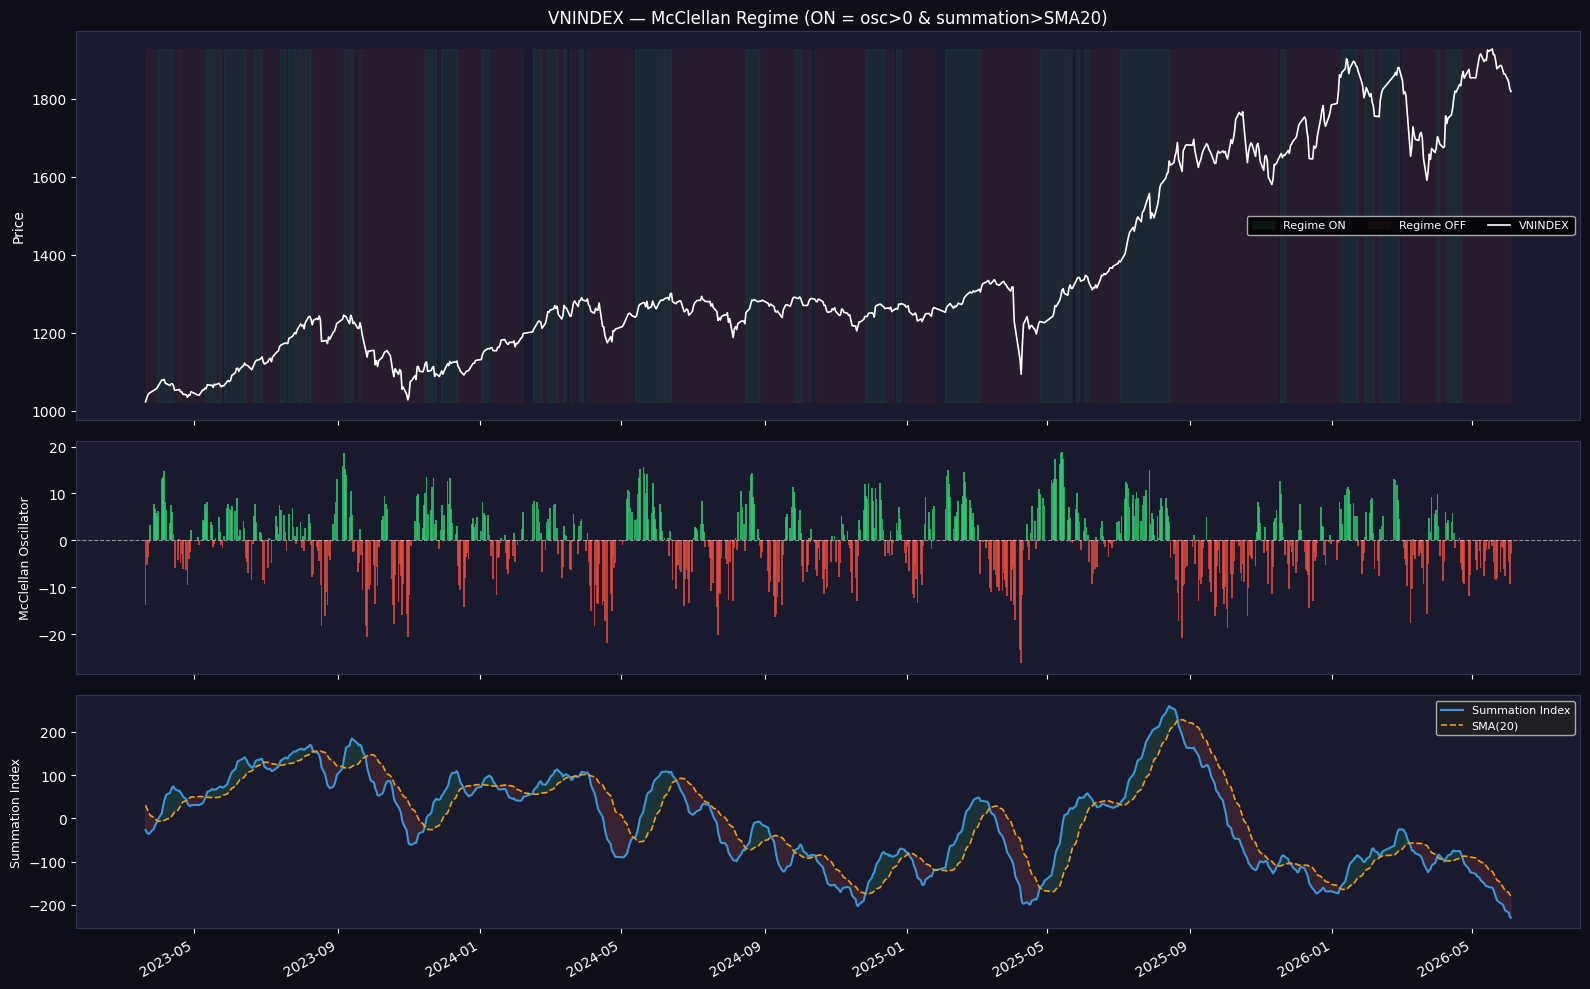

In [35]:
# ── Visualise McClellan Oscillator + Summation Index ─────────────────────────
LOOKBACK = 800
sl_      = slice(-LOOKBACK, None)

dates_v   = close.index[sl_]
c_vn      = close['VNINDEX'].values[sl_]
osc_v     = mcl_osc.values[sl_]
summ_v    = mcl_summation.values[sl_]
sma_v     = mcl_sma_summ.values[sl_]
ron_v     = mcl_regime_on.values[sl_]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1.5, 1.5]})
fig.patch.set_facecolor('#0f0f1a')

# ── [0] VNINDEX price with regime shading ────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=ron_v,  color='#2ecc71', alpha=0.08, label='Regime ON')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=~ron_v, color='#e74c3c', alpha=0.06, label='Regime OFF')
ax.plot(dates_v, c_vn, color='white', lw=1.2, label='VNINDEX')
ax.set_title('VNINDEX — McClellan Regime (ON = osc>0 & summation>SMA20)',
             color='white', fontsize=12)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=8, ncol=3)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# ── [1] McClellan Oscillator histogram ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_osc = np.where(osc_v >= 0, '#2ecc71', '#e74c3c')
ax2.bar(dates_v, osc_v, color=colors_osc, width=1.5, alpha=0.8)
ax2.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax2.set_ylabel('McClellan Oscillator', color='white', fontsize=9)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

# ── [2] Summation Index vs SMA ────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
ax3.plot(dates_v, summ_v, color='#3498db', lw=1.5, label='Summation Index')
ax3.plot(dates_v, sma_v,  color='#f39c12', lw=1.2, ls='--',
         label=f'SMA({MCL_SMA_WINDOW})')
ax3.fill_between(dates_v, summ_v, sma_v,
                 where=(summ_v >= sma_v), color='#2ecc71', alpha=0.15)
ax3.fill_between(dates_v, summ_v, sma_v,
                 where=(summ_v <  sma_v), color='#e74c3c', alpha=0.15)
ax3.set_ylabel('Summation Index', color='white', fontsize=9)
ax3.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax3.tick_params(colors='white')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax3.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()


In [36]:
# Optuna best params (005d search space — 17 tunable keys + GKYZ regime)
FIXED_TTM_PARAMS = {
    'v1': {
        'bb_window': 19, 'bb_multiplier': 1.3, 'bb_matype': 3,
        'kc_window': 55, 'kc_multiplier': 1.2, 'kc_atr_period': 6,
        'donichan_window': 10, 'osc_smoothing_period': 5,
        'low_stop_lookback': 5,
        'avwap_window': 160,
        'kama_period': 10, 'kama_fast': 5, 'kama_slow': 25,
        'kama_slope_win': 5, 'flat_threshold_pct': 3.0,
        'gkyz_window': 21, 'gkyz_upper': 0.8,        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0,    },
    'v2': {
        'bb_window': 12, 'bb_multiplier': 1.4, 'bb_matype': 3,
        'kc_window': 47, 'kc_multiplier': 1.3, 'kc_atr_period': 6,
        'donichan_window': 10, 'osc_smoothing_period': 5,
        'low_stop_lookback': 5,
        'avwap_window': 20,
        'kama_period': 14, 'kama_fast': 3, 'kama_slow': 25,
        'kama_slope_win': 3, 'flat_threshold_pct': 3.0,
        'gkyz_window': 21, 'gkyz_upper': 0.8,        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0,    },
    'v3': {
        'bb_window': 10, 'bb_multiplier': 1.7, 'bb_matype': 3,
        'kc_window': 27, 'kc_multiplier': 1.4, 'kc_atr_period': 5,
        'low_stop_lookback': 5,
        'consecutive_neg_threshold': 5, 'william_vix_period': 18,
        'avwap_window': 100,
        'kama_period': 6, 'kama_fast': 3, 'kama_slow': 34,
        'kama_slope_win': 18, 'flat_threshold_pct': 1.3,
        'gkyz_window': 21, 'gkyz_upper': 0.8,        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0,    },
}


## 6. Final Backtest — v1 / v2 / v3 + GKYZ Entry Filter & Comparison — Stats Table

In [37]:
portfolios_mcl = {}
portfolios_ttm = {}

for ver in ['v1', 'v2', 'v3']:
    p = FIXED_TTM_PARAMS[ver]

    entries = compute_signals(
        close, high, low, volume,
        bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
        bb_matype=p.get('bb_matype', 0),
        kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
        kc_atr_period=p['kc_atr_period'],
        donichan_window=p.get('donichan_window', 10),
        osc_smoothing_period=p.get('osc_smoothing_period', 5),
        entry_version=ver,
        consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
        william_vix_period=p.get('william_vix_period', 20),
        use_avwap_filter=True,
        avwap_window=p.get('avwap_window', 200),
        use_kama_slope=True,
        kama_period=p.get('kama_period', 10),
        kama_fast=p.get('kama_fast', 2),
        kama_slow=p.get('kama_slow', 30),
        kama_slope_win=p.get('kama_slope_win', 5),
        flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier=p.get('atr_multiplier', 1.9),
        atr_period=p.get('atr_period', 10),
        lookback=p.get('low_stop_lookback', 5),
    )

    print(f'Running {ver} (TTM, no filter) ...')
    pf_ttm = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits, sl_stop=sl_stop_df,
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_ttm[ver] = pf_ttm

    # McClellan regime is pre-computed once (market breadth — same for all symbols)
    print(f'Running {ver} + McClellan regime filter ...')
    entries_filtered = apply_mcclellan_filter(entries, mcl_regime_on, ver)

    pf_mcl = vbt.Portfolio.from_signals(
        close=close, entries=entries_filtered, exits=exits, sl_stop=sl_stop_df,
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_mcl[ver] = pf_mcl

    n_all  = int(entries.sum().sum())
    n_filt = int(entries_filtered.sum().sum())
    print(f'  TTM  trades={int(pf_ttm.trades.count().sum()):,}')
    print(f'  MCL  trades={int(pf_mcl.trades.count().sum()):,}  ({n_filt/n_all*100:.1f}% entries passed gate)')


def version_stats(label, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy':         label,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [
    *[version_stats(f'Opt {v} (TTM)',  portfolios_ttm[v]) for v in ['v1', 'v2', 'v3']],
    *[version_stats(f'Opt {v} + MCL',  portfolios_mcl[v]) for v in ['v1', 'v2', 'v3']],
]
stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df


Running v1 (TTM, no filter) ...
Running v1 + McClellan regime filter ...
  TTM  trades=11,925
  MCL  trades=8,496  (49.7% entries passed gate)
Running v2 (TTM, no filter) ...
Running v2 + McClellan regime filter ...
  TTM  trades=13,893
  MCL  trades=7,385  (39.1% entries passed gate)
Running v3 (TTM, no filter) ...
Running v3 + McClellan regime filter ...
  TTM  trades=7,326
  MCL  trades=1,807  (21.8% entries passed gate)


Strategy,Opt v1 (TTM),Opt v2 (TTM),Opt v3 (TTM),Opt v1 + MCL,Opt v2 + MCL,Opt v3 + MCL
Sharpe mean,0.659,0.615,0.571,0.672,0.431,0.135
Sharpe median,0.655,0.618,0.602,0.673,0.463,0.158
Sharpe > 0,189/197,188/197,182/197,188/197,179/197,128/197
Sharpe > 1,39/197,29/197,27/197,38/197,13/197,3/197
Sortino mean,1.034,0.961,0.905,1.079,0.691,0.258
Calmar mean,0.431,0.389,0.382,0.482,0.267,0.11
Total Ret mean,417.3%,322.9%,204.9%,298.2%,109.6%,16.7%
Total Ret median,197.7%,168.6%,128.0%,157.8%,69.5%,7.3%
Max DD mean,-49.5%,-51.2%,-41.5%,-39.0%,-39.0%,-23.8%
Max DD worst,-96.0%,-97.6%,-87.6%,-73.3%,-79.4%,-75.8%


## 11. Sharpe Distribution — McClellan Filter vs No Filter

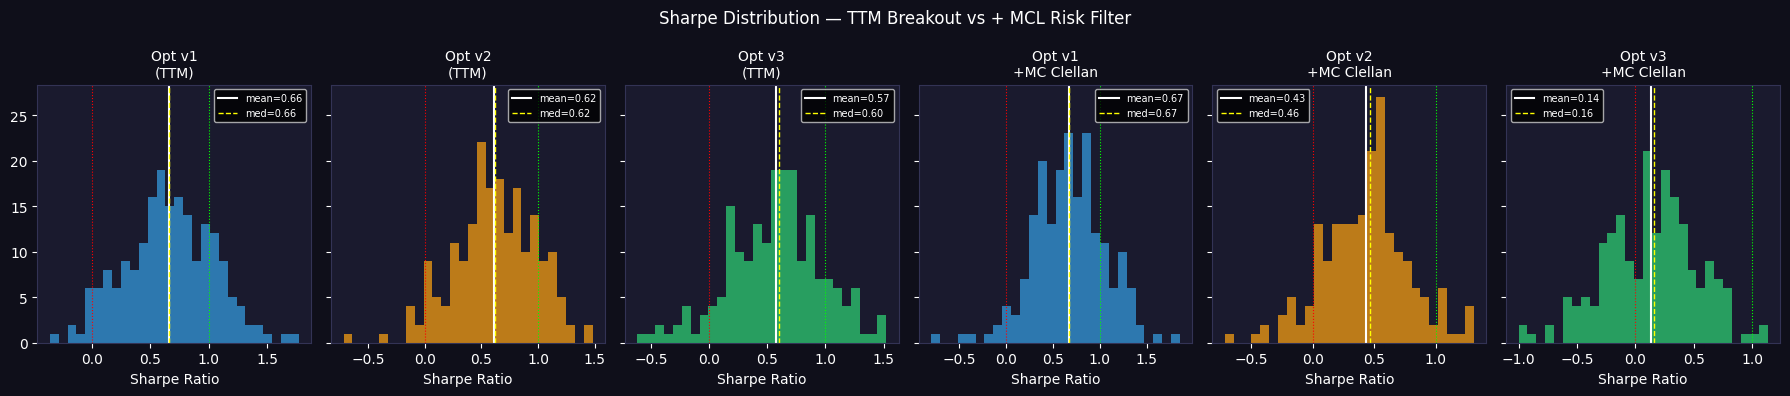

In [38]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

entries_list = [
    *[(f'Opt {v}\n(TTM)',  portfolios_ttm[v],  COLORS[v]) for v in ['v1', 'v2', 'v3']],
    *[(f'Opt {v}\n+MC Clellan', portfolios_mcl[v], COLORS[v]) for v in ['v1', 'v2', 'v3']],
]

n = len(entries_list)
fig, axes = plt.subplots(1, n, figsize=(max(18, 3.0 * n), 4), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='-',  label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red',  lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — TTM Breakout vs + MCL Risk Filter', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Delta Sharpe vs Baseline (No Filter)

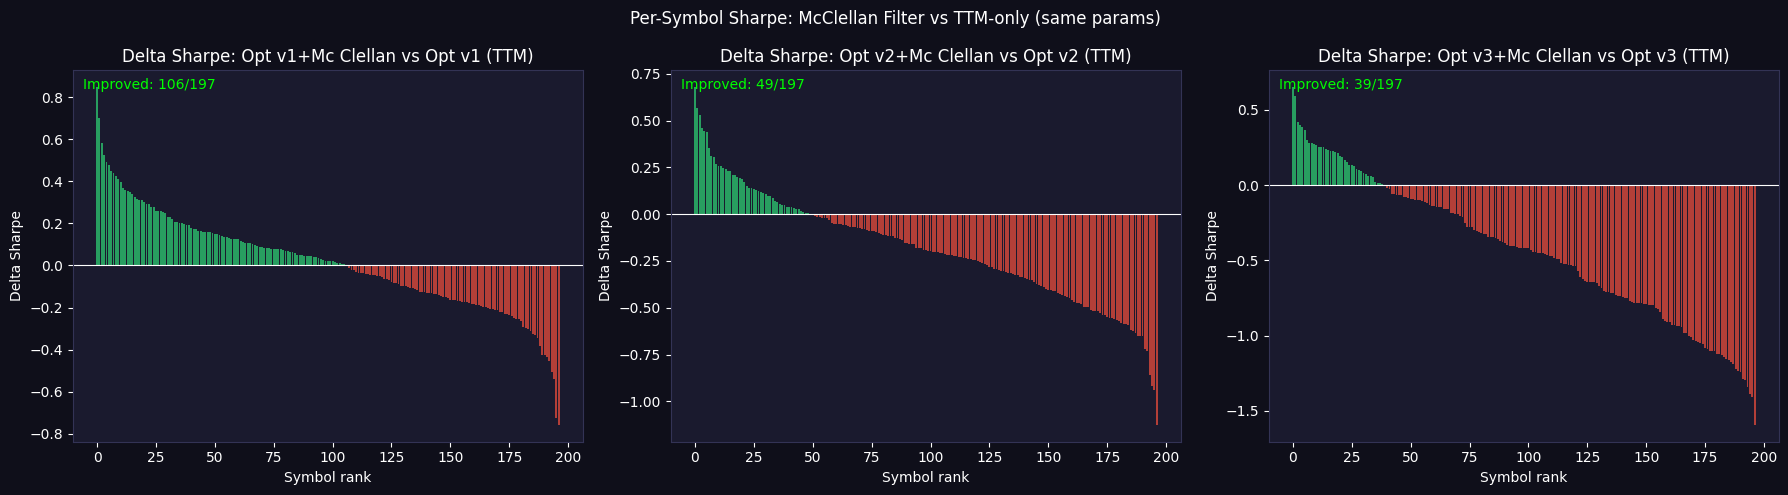

In [39]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    sr_ttm  = portfolios_ttm[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    sr_gkyz = portfolios_mcl[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    delta   = (sr_gkyz - sr_ttm).dropna().sort_values(ascending=False)
    colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.75)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: Opt {ver}+Mc Clellan vs Opt {ver} (TTM)', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    improved = (delta > 0).sum()
    ax.text(0.02, 0.95, f'Improved: {improved}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe: McClellan Filter vs TTM-only (same params)', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Single-Symbol — TTM Entries with GKYZ Regime Overlay

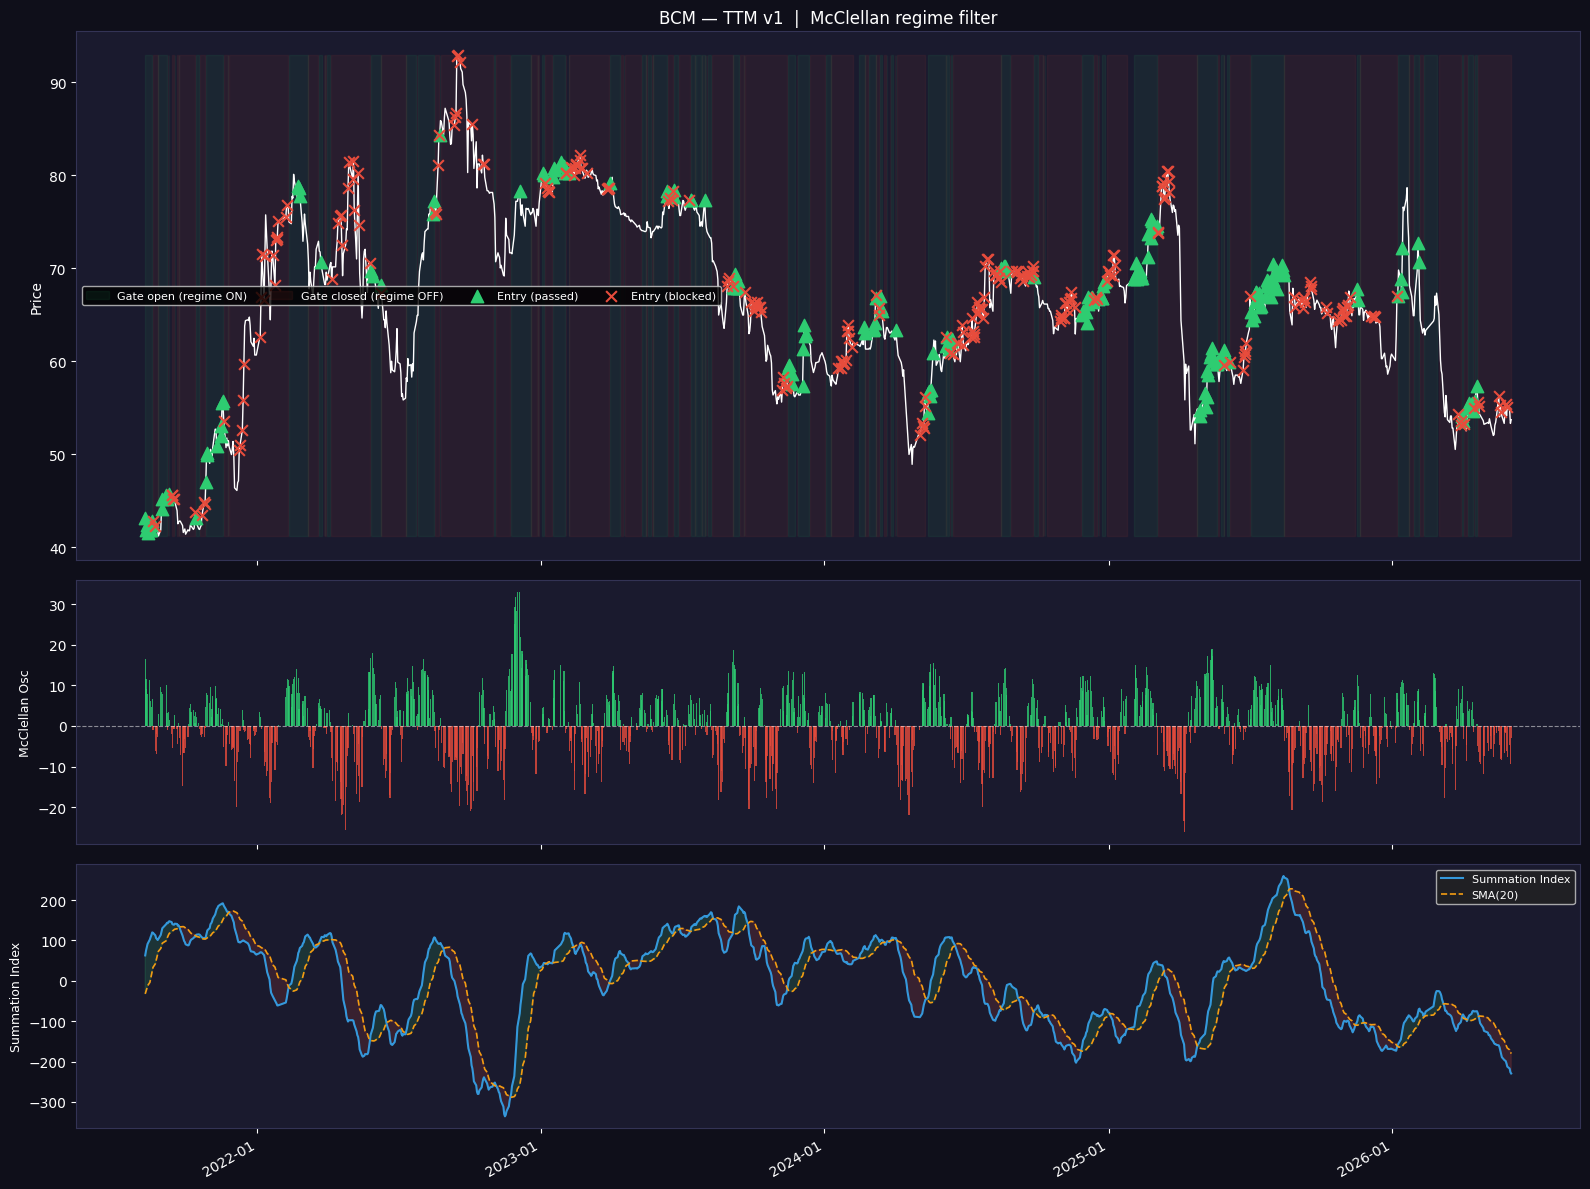

BCM | Sharpe: 0.925  Total Ret: 361.6%  [McClellan regime]


In [41]:
LOOKBACK_DAYS = 1200
def plot_ttm_entries(VER, SYMBOL):
    p = FIXED_TTM_PARAMS[VER]

    ttm_entries_raw = compute_signals(
        close, high, low, volume,
        bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
        bb_matype=p.get('bb_matype', 0),
        kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
        kc_atr_period=p['kc_atr_period'],
        donichan_window=p['donichan_window'], osc_smoothing_period=p['osc_smoothing_period'],
        entry_version=VER,
        consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
        william_vix_period=p.get('william_vix_period', 20),
        use_avwap_filter=True, avwap_window=p.get('avwap_window', 200),
        use_kama_slope=True,
        kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
        kama_slow=p.get('kama_slow', 30),     kama_slope_win=p.get('kama_slope_win', 5),
        flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
    )

    dates  = close.index
    n_show = min(LOOKBACK_DAYS, len(dates))
    sl_    = slice(-n_show, None)
    dates_s = dates[sl_]
    c_s     = close[SYMBOL].values[sl_]

    ttm_raw  = ttm_entries_raw[SYMBOL].values.astype(bool)[sl_]
    osc_s    = mcl_osc.values[sl_]
    summ_s   = mcl_summation.values[sl_]
    sma_s    = mcl_sma_summ.values[sl_]
    gate_arr = mcl_regime_on.values[sl_]

    entry_passed  = ttm_raw &  gate_arr
    entry_blocked = ttm_raw & ~gate_arr

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                            gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
    fig.patch.set_facecolor('#0f0f1a')

    # ── [0] Price + entry markers ─────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor('#1a1a2e')
    ax.fill_between(dates_s, c_s.min(), c_s.max(), where=gate_arr,
                    color='#2ecc71', alpha=0.07, label='Gate open (regime ON)')
    ax.fill_between(dates_s, c_s.min(), c_s.max(), where=~gate_arr,
                    color='#e74c3c', alpha=0.07, label='Gate closed (regime OFF)')
    ax.plot(dates_s, c_s, color='white', lw=1.0)
    ax.scatter(dates_s[entry_passed],  c_s[entry_passed],
            marker='^', color='#2ecc71', s=80, zorder=5, label='Entry (passed)')
    ax.scatter(dates_s[entry_blocked], c_s[entry_blocked],
            marker='x', color='#e74c3c', s=60, zorder=5, label='Entry (blocked)')
    ax.set_title(f'{SYMBOL} — TTM {VER}  |  McClellan regime filter', color='white', fontsize=12)
    ax.set_ylabel('Price', color='white')
    ax.legend(fontsize=8, ncol=4)
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

    # ── [1] McClellan Oscillator ──────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a2e')
    colors_osc = np.where(osc_s >= 0, '#2ecc71', '#e74c3c')
    ax2.bar(dates_s, osc_s, color=colors_osc, width=1.5, alpha=0.8)
    ax2.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
    ax2.set_ylabel('McClellan Osc', color='white', fontsize=9)
    ax2.tick_params(colors='white')
    for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

    # ── [2] Summation Index vs SMA ────────────────────────────────────────────────
    ax3 = axes[2]
    ax3.set_facecolor('#1a1a2e')
    ax3.plot(dates_s, summ_s, color='#3498db', lw=1.5, label='Summation Index')
    ax3.plot(dates_s, sma_s,  color='#f39c12', lw=1.2, ls='--',
            label=f'SMA({MCL_SMA_WINDOW})')
    ax3.fill_between(dates_s, summ_s, sma_s,
                    where=(summ_s >= sma_s), color='#2ecc71', alpha=0.15)
    ax3.fill_between(dates_s, summ_s, sma_s,
                    where=(summ_s <  sma_s), color='#e74c3c', alpha=0.15)
    ax3.set_ylabel('Summation Index', color='white', fontsize=9)
    ax3.legend(fontsize=8, facecolor='#222', labelcolor='white')
    ax3.tick_params(colors='white')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate(rotation=30)
    for sp in ax3.spines.values(): sp.set_edgecolor('#333355')

    plt.tight_layout()
    plt.show()

    pf_sym = portfolios_mcl[VER]
    print(f'{SYMBOL} | Sharpe: {pf_sym.sharpe_ratio()[SYMBOL]:.3f}  '
        f'Total Ret: {pf_sym.total_return()[SYMBOL]*100:.1f}%  [McClellan regime]')

VER           = 'v1'
plot_ttm_entries(VER, 'BCM')